Matplotlib is building the font cache; this may take a moment.



══════════════════════════════════════════════════════════════
  Monte Carlo Simulation Framework — Quantitative Finance
══════════════════════════════════════════════════════════════

[1/5]  Running single-asset GBM simulation …
  ✓ 10,000 paths × 252 time steps generated.

[2/5]  Generating risk report …

══════════════════════════════════════════════════════════════
  MONTE CARLO RISK REPORT  |  S&P 500 Proxy (SPY)
══════════════════════════════════════════════════════════════

  SIMULATION PARAMETERS
──────────────────────────────────────────────────────────────
  Asset                        S&P 500 Proxy (SPY)
  Initial Price (S0)           $500.00
  Drift (μ)                    8.00% p.a.
  Volatility (σ)               18.00% p.a.
  Time Horizon (T)             1.0 year(s)
  Time Step (dt)               1/252 (daily)
  Simulations (N)              10,000
  Random Seed                  42
  Portfolio Value              $1,000,000

  RETURN STATISTICS
────────────────────────────

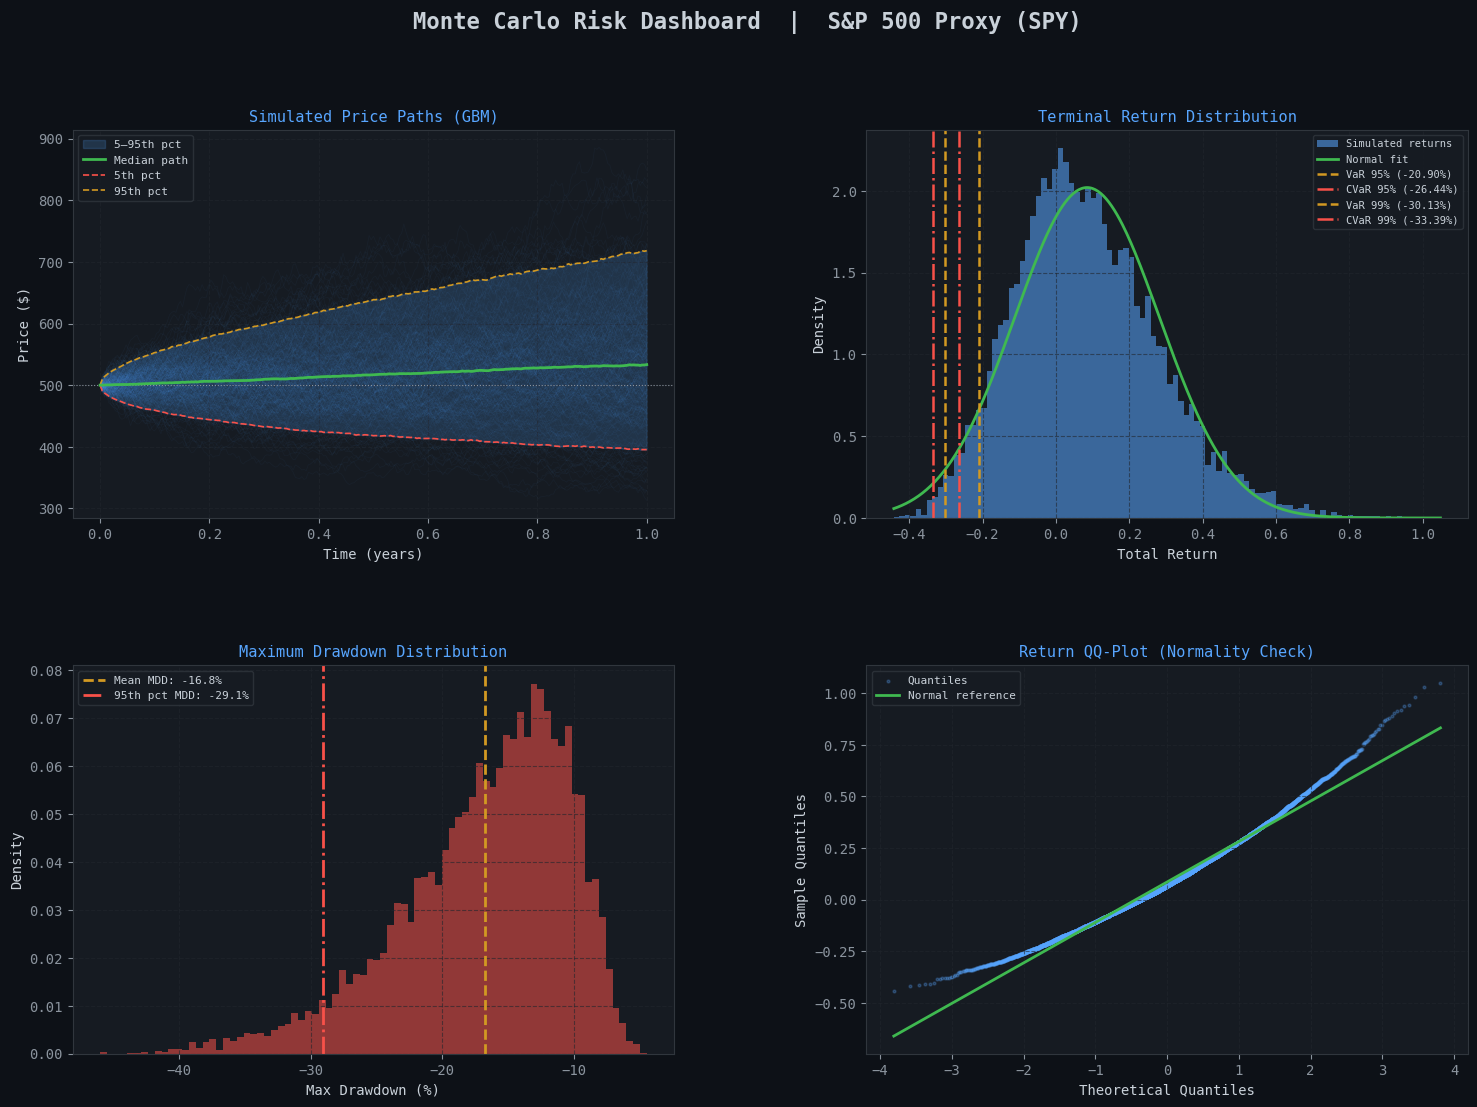

  ✓ Dashboard saved → mc_dashboard.png

[4/5]  Running scenario analysis …

  SCENARIO ANALYSIS RESULTS
         Volatility (σ) E[Return] Std(Return)  VaR 99% CVaR 99% E[Max Drawdown] Worst Drawdown
Scenario                                                                                      
Base                18%     8.51%      19.75%  -30.13%  -33.39%         -16.79%        -46.02%
Elevated            30%     8.64%      33.41%  -48.77%  -52.64%         -27.95%        -66.51%
Crisis              55%     8.94%      64.75%  -74.38%  -77.72%         -47.11%        -88.19%
Meltdown            80%     9.24%     102.82%  -87.96%  -90.12%         -61.58%        -96.08%


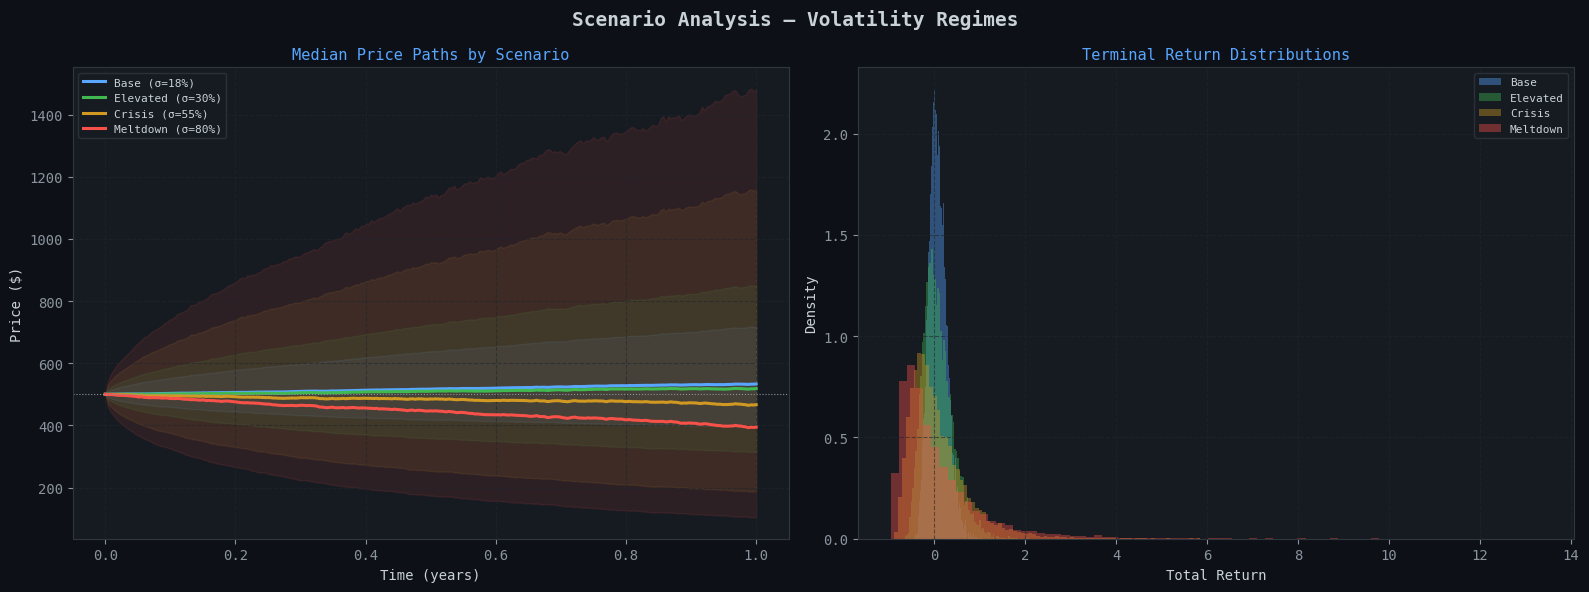

  ✓ Scenario chart saved → mc_scenarios.png

[5/5]  Running correlated multi-asset portfolio simulation …

  PORTFOLIO SUMMARY  (4-Asset, 10,000 simulations)
──────────────────────────────────────────────
  US Equity       μ=8%  σ=18%  w=40%
  EM Equity       μ=10%  σ=25%  w=20%
  Gov Bonds       μ=3%  σ=7%  w=30%
  Commodities     μ=5%  σ=22%  w=10%

  E[Portfolio Return]  : 7.6033%
  Std(Return)          : 17.0384%
  VaR 99%  (return)    : -25.0222%
  CVaR 99% (return)    : -28.3800%
  VaR 99%  ($)         : $-250,222
  CVaR 99% ($)         : $-283,800
  Mean Max Drawdown    : -14.6591%


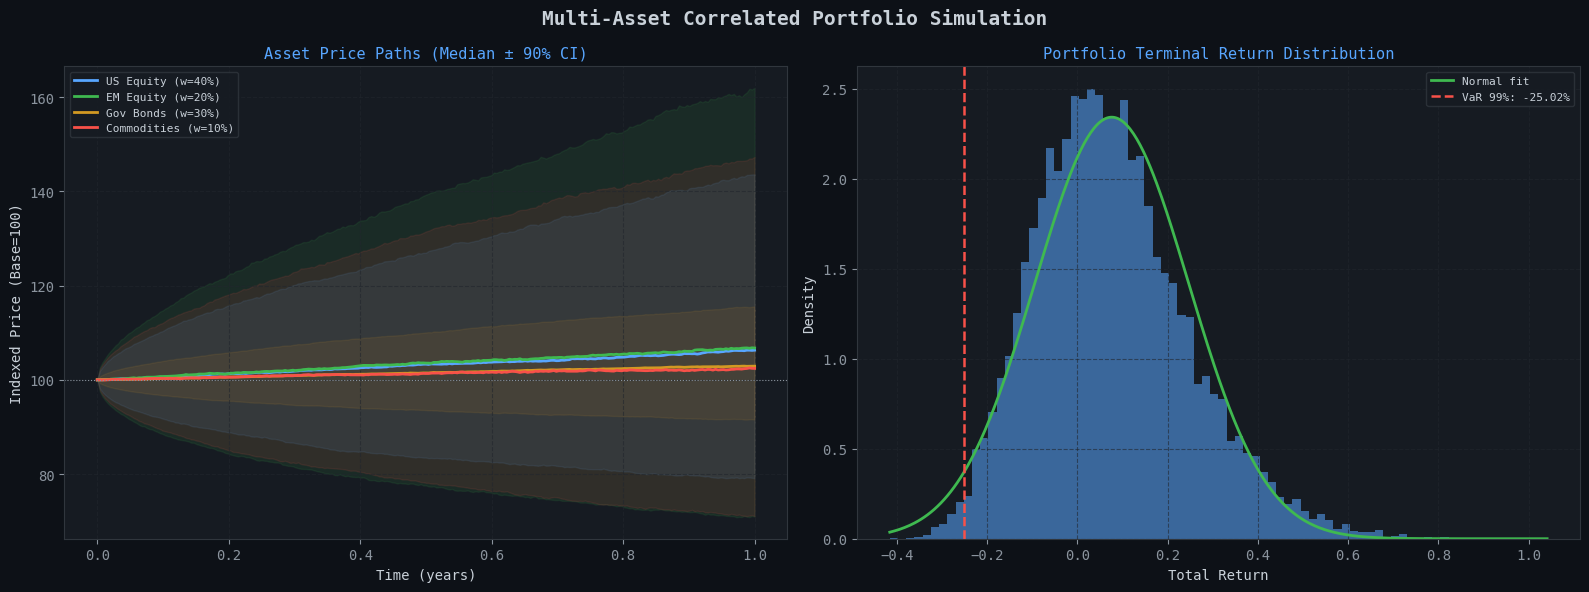

  ✓ Portfolio chart saved → mc_portfolio.png

  ✓ All outputs saved. Project execution complete.



In [1]:
"""
==============================================================================
 Monte Carlo Simulation Framework for Quantitative Finance
==============================================================================
 Author  : Elizabeth Saint-Wonder
 Purpose : Portfolio risk estimation, VaR/CVaR modelling, scenario analysis,
           and multi-asset correlated simulation using Geometric Brownian Motion (GBM)
 Stack   : numpy · pandas · matplotlib · scipy
 Steps outlined in numbers!!
==============================================================================
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.stats import norm
import warnings

warnings.filterwarnings("ignore")

# Global Alignment
plt.rcParams.update({
    "figure.facecolor": "#0d1117",
    "axes.facecolor":   "#161b22",
    "axes.edgecolor":   "#30363d",
    "axes.labelcolor":  "#c9d1d9",
    "xtick.color":      "#8b949e",
    "ytick.color":      "#8b949e",
    "text.color":       "#c9d1d9",
    "grid.color":       "#21262d",
    "grid.linestyle":   "--",
    "grid.alpha":       0.6,
    "legend.facecolor": "#161b22",
    "legend.edgecolor": "#30363d",
    "font.family":      "monospace",
})

ACCENT   = "#58a6ff"   # blue
ACCENT2  = "#3fb950"   # green
DANGER   = "#f85149"   # red
WARNING  = "#d29922"   # amber
MUTED    = "#8b949e"   # grey


# ==============================================================================
# 1. CORE SIMULATION ENGINE
# ==============================================================================

def simulate_price_paths(
    S0: float,
    mu: float,
    sigma: float,
    T: float,
    dt: float,
    n_simulations: int,
    seed: int = 42,
) -> np.ndarray:
    """
    Simulate asset price paths via Geometric Brownian Motion (GBM).

    The GBM SDE:  dS = μ·S·dt + σ·S·dW
    Closed-form solution (log-normal):
        S(t) = S0 · exp[(μ - σ²/2)·t + σ·√t·Z],  Z ~ N(0,1)

    Parameters
    ----------
    S0            : float  – Initial asset price (e.g. $100)
    mu            : float  – Annualised drift / expected return (e.g. 0.08 = 8 %)
    sigma         : float  – Annualised volatility (e.g. 0.20 = 20 %)
    T             : float  – Time horizon in years (e.g. 1.0 = 1 year)
    dt            : float  – Time step size (e.g. 1/252 = 1 trading day)
    n_simulations : int    – Number of Monte Carlo paths
    seed          : int    – Random seed for full reproducibility

    Returns
    -------
    np.ndarray of shape (n_steps + 1, n_simulations)
        Each column is one simulated price path.
    """
    rng     = np.random.default_rng(seed)
    n_steps = int(T / dt)

    # Vectorised GBM: draw all random shocks at once (n_steps × n_simulations)
    Z       = rng.standard_normal((n_steps, n_simulations))

    # Daily log-return increments
    # ln(S_t / S_{t-1}) = (μ - σ²/2)·dt + σ·√dt·Z
    log_returns = (mu - 0.5 * sigma ** 2) * dt + sigma * np.sqrt(dt) * Z

    # Cumulative sum → cumulative log-price → price paths
    log_price_paths          = np.cumsum(log_returns, axis=0)
    price_paths              = np.exp(log_price_paths) * S0

    # Prepend initial price row
    initial_row              = np.full((1, n_simulations), S0)
    price_paths              = np.vstack([initial_row, price_paths])

    return price_paths  # shape: (n_steps+1, n_simulations)


def calculate_returns(price_paths: np.ndarray) -> np.ndarray:
    """
    Compute total returns at terminal date for each simulation path.

    Returns
    -------
    np.ndarray – 1-D array of terminal total returns (e.g. 0.12 = +12 %).
    """
    terminal_prices  = price_paths[-1, :]
    initial_price    = price_paths[0, 0]
    total_returns    = (terminal_prices - initial_price) / initial_price
    return total_returns


def compute_var_cvar(
    returns: np.ndarray,
    confidence_levels: list = [0.95, 0.99],
    initial_investment: float = 1_000_000,
) -> dict:
    """
    Compute Value at Risk (VaR) and Conditional Value at Risk (CVaR / Expected
    Shortfall) at multiple confidence levels.

    VaR(α)  = The loss not exceeded with probability α.
    CVaR(α) = Expected loss given that loss exceeds VaR(α).

    Parameters
    ----------
    returns             : np.ndarray – Terminal total returns (fractional)
    confidence_levels   : list       – e.g. [0.95, 0.99]
    initial_investment  : float      – Portfolio face value for £/$ translation

    Returns
    -------
    dict with keys: 'var_pct', 'cvar_pct', 'var_dollar', 'cvar_dollar'
    """
    results = {}
    for cl in confidence_levels:
        alpha          = 1 - cl
        var_pct        = np.percentile(returns, alpha * 100)
        tail_returns   = returns[returns <= var_pct]
        cvar_pct       = tail_returns.mean() if len(tail_returns) > 0 else var_pct

        results[cl] = {
            "var_pct"     : var_pct,
            "cvar_pct"    : cvar_pct,
            "var_dollar"  : var_pct  * initial_investment,
            "cvar_dollar" : cvar_pct * initial_investment,
        }
    return results


def compute_max_drawdown(price_paths: np.ndarray) -> np.ndarray:
    """
    Compute the Maximum Drawdown (MDD) for each simulated path.

    MDD = max peak-to-trough decline over the simulation horizon.

    Returns
    -------
    np.ndarray – 1-D array of MDD values (negative, e.g. -0.35 = -35 %).
    """
    n_simulations = price_paths.shape[1]
    max_drawdowns = np.zeros(n_simulations)

    # Vectorised rolling peak
    running_max   = np.maximum.accumulate(price_paths, axis=0)
    drawdowns     = (price_paths - running_max) / running_max
    max_drawdowns = drawdowns.min(axis=0)

    return max_drawdowns


# ==============================================================================
# 2. MULTI-ASSET CORRELATED SIMULATION (Extension A)
# ==============================================================================

def simulate_correlated_portfolio(
    S0_vec: np.ndarray,
    mu_vec: np.ndarray,
    sigma_vec: np.ndarray,
    corr_matrix: np.ndarray,
    weights: np.ndarray,
    T: float,
    dt: float,
    n_simulations: int,
    seed: int = 42,
) -> dict:
    """
    Simulate a multi-asset portfolio using correlated GBM via Cholesky
    decomposition.

    Cholesky decomposition factorises the correlation matrix Σ = L·Lᵀ so
    that correlated shocks Z_corr = L·Z_indep preserve pairwise correlations.

    Parameters
    ----------
    S0_vec      : 1-D array – Initial prices for each asset
    mu_vec      : 1-D array – Annualised drifts
    sigma_vec   : 1-D array – Annualised volatilities
    corr_matrix : 2-D array – Asset correlation matrix (must be PSD)
    weights     : 1-D array – Portfolio weights (must sum to 1)
    T, dt, n_simulations, seed: same as simulate_price_paths()

    Returns
    -------
    dict with:
      'asset_paths'        : list of price path arrays per asset
      'portfolio_values'   : portfolio value path (n_steps+1, n_sims)
      'portfolio_returns'  : terminal returns
    """
    assert np.isclose(weights.sum(), 1.0), "Weights must sum to 1."

    rng         = np.random.default_rng(seed)
    n_assets    = len(S0_vec)
    n_steps     = int(T / dt)
    L           = np.linalg.cholesky(corr_matrix)          # Cholesky factor

    # Simulate correlated standard normals: shape (n_steps, n_assets, n_sims)
    Z_indep     = rng.standard_normal((n_steps, n_assets, n_simulations))
    # Einsum applies L to the asset dimension
    Z_corr      = np.einsum("ij,tjk->tik", L, Z_indep)

    asset_paths = []
    for i in range(n_assets):
        log_returns   = ((mu_vec[i] - 0.5 * sigma_vec[i] ** 2) * dt
                         + sigma_vec[i] * np.sqrt(dt) * Z_corr[:, i, :])
        cum_log       = np.cumsum(log_returns, axis=0)
        paths         = np.exp(cum_log) * S0_vec[i]
        paths         = np.vstack([np.full((1, n_simulations), S0_vec[i]), paths])
        asset_paths.append(paths)

    # Portfolio value = weighted sum of individual asset values
    # Normalise each asset by its initial price before applying weights
    portfolio_values = np.zeros_like(asset_paths[0])
    initial_port_val = np.dot(weights, S0_vec)
    for i, paths in enumerate(asset_paths):
        portfolio_values += weights[i] * paths

    portfolio_returns = (portfolio_values[-1, :] - portfolio_values[0, 0]) / portfolio_values[0, 0]

    return {
        "asset_paths"       : asset_paths,
        "portfolio_values"  : portfolio_values,
        "portfolio_returns" : portfolio_returns,
    }


# ==============================================================================
# 3. SCENARIO ANALYSIS : VOLATILITY SHOCK (Extension B)
# ==============================================================================

def scenario_analysis(
    S0: float,
    mu: float,
    sigma_base: float,
    sigma_shocks: dict,
    T: float,
    dt: float,
    n_simulations: int,
    confidence_level: float = 0.99,
    seed: int = 42,
) -> pd.DataFrame:
    """
    Run scenario analysis across multiple volatility regimes.

    Compares base-case simulation against stress scenarios (e.g. VIX spike,
    crisis-level vol) to quantify tail risk sensitivity.

    Parameters
    ----------
    sigma_shocks : dict – {'label': sigma_value}, e.g.
                          {'Base': 0.20, 'Elevated': 0.35, 'Crisis': 0.60}

    Returns
    -------
    pd.DataFrame – Summary risk metrics per scenario.
    """
    records = []
    all_scenarios = {"Base": sigma_base, **sigma_shocks}

    for label, sigma in all_scenarios.items():
        paths    = simulate_price_paths(S0, mu, sigma, T, dt, n_simulations, seed)
        rets     = calculate_returns(paths)
        risk     = compute_var_cvar(rets, [confidence_level])
        mdd      = compute_max_drawdown(paths)

        records.append({
            "Scenario"         : label,
            "Volatility (σ)"   : f"{sigma:.0%}",
            "E[Return]"        : f"{rets.mean():.2%}",
            "Std(Return)"      : f"{rets.std():.2%}",
            f"VaR {confidence_level:.0%}"  : f"{risk[confidence_level]['var_pct']:.2%}",
            f"CVaR {confidence_level:.0%}" : f"{risk[confidence_level]['cvar_pct']:.2%}",
            "E[Max Drawdown]"  : f"{mdd.mean():.2%}",
            "Worst Drawdown"   : f"{mdd.min():.2%}",
        })

    return pd.DataFrame(records).set_index("Scenario")


# ==============================================================================
# 4. VISUALISATION ENGINE
# ==============================================================================

def plot_simulations(
    price_paths: np.ndarray,
    returns: np.ndarray,
    var_cvar: dict,
    max_drawdowns: np.ndarray,
    dt: float,
    ticker: str = "Asset",
    save_path: str = None,
):
    """
    Publication-quality 4-panel dashboard:
      Panel 1 – Simulated price paths (fan chart)
      Panel 2 – Terminal return distribution with VaR/CVaR overlays
      Panel 3 – Drawdown distribution
      Panel 4 – Annual return QQ-plot (normality check)
    """
    n_steps      = price_paths.shape[0] - 1
    t_axis       = np.linspace(0, n_steps * dt, n_steps + 1)
    n_plot_paths = min(300, price_paths.shape[1])

    fig = plt.figure(figsize=(18, 12))
    fig.suptitle(
        f"Monte Carlo Risk Dashboard  |  {ticker}",
        fontsize=16, fontweight="bold", color="#c9d1d9", y=0.98,
    )
    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.32)

    # ── Panel 1: Price Paths ─────────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.set_title("Simulated Price Paths (GBM)", color=ACCENT, fontsize=11)

    for i in range(n_plot_paths):
        ax1.plot(t_axis, price_paths[:, i], alpha=0.04, lw=0.6, color=ACCENT)

    # Percentile fan
    pct_lo  = np.percentile(price_paths, 5,  axis=1)
    pct_hi  = np.percentile(price_paths, 95, axis=1)
    pct_med = np.percentile(price_paths, 50, axis=1)

    ax1.fill_between(t_axis, pct_lo, pct_hi, alpha=0.18, color=ACCENT, label="5–95th pct")
    ax1.plot(t_axis, pct_med,  color=ACCENT2, lw=2.0,  label="Median path", zorder=5)
    ax1.plot(t_axis, pct_lo,   color=DANGER,  lw=1.2,  linestyle="--", label="5th pct")
    ax1.plot(t_axis, pct_hi,   color=WARNING, lw=1.2,  linestyle="--", label="95th pct")
    ax1.axhline(price_paths[0, 0], color=MUTED, lw=0.8, linestyle=":")

    ax1.set_xlabel("Time (years)")
    ax1.set_ylabel("Price ($)")
    ax1.legend(fontsize=8, loc="upper left")
    ax1.grid(True)

    # ── Panel 2: Return Distribution + VaR/CVaR ──────────────────────────────
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.set_title("Terminal Return Distribution", color=ACCENT, fontsize=11)

    ax2.hist(
        returns, bins=100, color=ACCENT, alpha=0.55, density=True,
        edgecolor="none", label="Simulated returns",
    )

    # Overlay normal fit
    mu_fit, std_fit = returns.mean(), returns.std()
    x_fit = np.linspace(returns.min(), returns.max(), 400)
    ax2.plot(x_fit, norm.pdf(x_fit, mu_fit, std_fit),
             color=ACCENT2, lw=2.0, label="Normal fit")

    for cl, metrics in var_cvar.items():
        v  = metrics["var_pct"]
        cv = metrics["cvar_pct"]
        ax2.axvline(v,  color=WARNING, lw=1.8, linestyle="--",
                    label=f"VaR {cl:.0%} ({v:.2%})")
        ax2.axvline(cv, color=DANGER,  lw=1.8, linestyle="-.",
                    label=f"CVaR {cl:.0%} ({cv:.2%})")

    ax2.set_xlabel("Total Return")
    ax2.set_ylabel("Density")
    ax2.legend(fontsize=7.5)
    ax2.grid(True)

    # ── Panel 3: Max Drawdown Distribution ───────────────────────────────────
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.set_title("Maximum Drawdown Distribution", color=ACCENT, fontsize=11)

    ax3.hist(
        max_drawdowns * 100, bins=80, color=DANGER, alpha=0.55, density=True,
        edgecolor="none",
    )
    mdd_mean = max_drawdowns.mean() * 100
    mdd_p95  = np.percentile(max_drawdowns, 5) * 100  # 5th pct is worst

    ax3.axvline(mdd_mean, color=WARNING, lw=2.0, linestyle="--",
                label=f"Mean MDD: {mdd_mean:.1f}%")
    ax3.axvline(mdd_p95,  color=DANGER,  lw=2.0, linestyle="-.",
                label=f"95th pct MDD: {mdd_p95:.1f}%")

    ax3.set_xlabel("Max Drawdown (%)")
    ax3.set_ylabel("Density")
    ax3.legend(fontsize=8)
    ax3.grid(True)

    # ── Panel 4: QQ Plot (normality check) ───────────────────────────────────
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.set_title("Return QQ-Plot (Normality Check)", color=ACCENT, fontsize=11)

    (osm, osr), (slope, intercept, _) = stats.probplot(returns, dist="norm")
    ax4.scatter(osm, osr, alpha=0.25, s=4, color=ACCENT, label="Quantiles")
    x_line = np.array([min(osm), max(osm)])
    ax4.plot(x_line, slope * x_line + intercept, color=ACCENT2, lw=2.0,
             label="Normal reference")
    ax4.set_xlabel("Theoretical Quantiles")
    ax4.set_ylabel("Sample Quantiles")
    ax4.legend(fontsize=8)
    ax4.grid(True)

    plt.savefig(save_path or "mc_dashboard.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  ✓ Dashboard saved → {save_path or 'mc_dashboard.png'}")


def plot_scenario_analysis(
    S0: float,
    mu: float,
    sigma_scenarios: dict,
    T: float,
    dt: float,
    n_simulations: int,
    seed: int = 42,
    save_path: str = None,
):
    """
    Overlay median price paths and return distributions for multiple vol regimes.
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle("Scenario Analysis — Volatility Regimes",
                 fontsize=14, fontweight="bold", color="#c9d1d9")

    palette = [ACCENT, ACCENT2, WARNING, DANGER, "#bc8cff"]
    n_steps = int(T / dt)
    t_axis  = np.linspace(0, T, n_steps + 1)

    ax1, ax2 = axes
    ax1.set_title("Median Price Paths by Scenario", color=ACCENT, fontsize=11)
    ax2.set_title("Terminal Return Distributions",  color=ACCENT, fontsize=11)

    for idx, (label, sigma) in enumerate(sigma_scenarios.items()):
        color = palette[idx % len(palette)]
        paths = simulate_price_paths(S0, mu, sigma, T, dt, n_simulations, seed)
        rets  = calculate_returns(paths)

        median_path = np.percentile(paths, 50, axis=1)
        lo_path     = np.percentile(paths,  5, axis=1)
        hi_path     = np.percentile(paths, 95, axis=1)

        ax1.plot(t_axis, median_path, color=color, lw=2.2, label=f"{label} (σ={sigma:.0%})")
        ax1.fill_between(t_axis, lo_path, hi_path, alpha=0.10, color=color)

        ax2.hist(rets, bins=80, color=color, alpha=0.40, density=True, label=f"{label}")

    ax1.axhline(S0, color=MUTED, lw=0.8, linestyle=":")
    ax1.set_xlabel("Time (years)"); ax1.set_ylabel("Price ($)")
    ax1.legend(fontsize=8); ax1.grid(True)

    ax2.set_xlabel("Total Return"); ax2.set_ylabel("Density")
    ax2.legend(fontsize=8); ax2.grid(True)

    plt.tight_layout()
    plt.savefig(save_path or "mc_scenarios.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  ✓ Scenario chart saved → {save_path or 'mc_scenarios.png'}")


def plot_correlated_portfolio(
    portfolio_data: dict,
    asset_labels: list,
    weights: np.ndarray,
    T: float,
    dt: float,
    save_path: str = None,
):
    """
    Plot multi-asset correlated simulation results:
      Left  – Individual asset median paths
      Right – Portfolio value distribution
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle("Multi-Asset Correlated Portfolio Simulation",
                 fontsize=14, fontweight="bold", color="#c9d1d9")

    palette  = [ACCENT, ACCENT2, WARNING, DANGER, "#bc8cff"]
    n_steps  = int(T / dt)
    t_axis   = np.linspace(0, T, n_steps + 1)

    ax1, ax2 = axes
    ax1.set_title("Asset Price Paths (Median ± 90% CI)", color=ACCENT, fontsize=11)

    for idx, (paths, label) in enumerate(zip(portfolio_data["asset_paths"], asset_labels)):
        color = palette[idx % len(palette)]
        med   = np.percentile(paths, 50, axis=1)
        lo    = np.percentile(paths,  5, axis=1)
        hi    = np.percentile(paths, 95, axis=1)

        # Normalise to 100 for comparability
        med_n = med / med[0] * 100
        lo_n  = lo  / lo[0]  * 100
        hi_n  = hi  / hi[0]  * 100

        ax1.plot(t_axis, med_n, color=color, lw=2.0,
                 label=f"{label} (w={weights[idx]:.0%})")
        ax1.fill_between(t_axis, lo_n, hi_n, alpha=0.10, color=color)

    ax1.axhline(100, color=MUTED, lw=0.8, linestyle=":")
    ax1.set_xlabel("Time (years)"); ax1.set_ylabel("Indexed Price (Base=100)")
    ax1.legend(fontsize=8); ax1.grid(True)

    # Portfolio return distribution
    port_rets = portfolio_data["portfolio_returns"]
    ax2.set_title("Portfolio Terminal Return Distribution", color=ACCENT, fontsize=11)
    ax2.hist(port_rets, bins=80, color=ACCENT, alpha=0.55, density=True, edgecolor="none")

    mu_p, sig_p = port_rets.mean(), port_rets.std()
    x_fit = np.linspace(port_rets.min(), port_rets.max(), 400)
    ax2.plot(x_fit, norm.pdf(x_fit, mu_p, sig_p), color=ACCENT2, lw=2.0, label="Normal fit")

    var_99 = np.percentile(port_rets, 1)
    ax2.axvline(var_99, color=DANGER, lw=1.8, linestyle="--", label=f"VaR 99%: {var_99:.2%}")

    ax2.set_xlabel("Total Return"); ax2.set_ylabel("Density")
    ax2.legend(fontsize=8); ax2.grid(True)

    plt.tight_layout()
    plt.savefig(save_path or "mc_portfolio.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  ✓ Portfolio chart saved → {save_path or 'mc_portfolio.png'}")


# ==============================================================================
# 5. REPORTING
# ==============================================================================

def print_risk_report(
    ticker: str,
    params: dict,
    returns: np.ndarray,
    var_cvar: dict,
    max_drawdowns: np.ndarray,
):
    """Print a structured risk report to stdout."""
    sep  = "─" * 62
    sep2 = "═" * 62

    print(f"\n{sep2}")
    print(f"  MONTE CARLO RISK REPORT  |  {ticker}")
    print(sep2)

    print(f"\n  SIMULATION PARAMETERS")
    print(sep)
    for k, v in params.items():
        print(f"  {k:<28} {v}")

    print(f"\n  RETURN STATISTICS")
    print(sep)
    pcts = [1, 5, 25, 50, 75, 95, 99]
    print(f"  {'Mean Return':<28} {returns.mean():>10.4%}")
    print(f"  {'Median Return':<28} {np.median(returns):>10.4%}")
    print(f"  {'Std Dev (Return)':<28} {returns.std():>10.4%}")
    print(f"  {'Skewness':<28} {stats.skew(returns):>10.4f}")
    print(f"  {'Excess Kurtosis':<28} {stats.kurtosis(returns):>10.4f}")
    for p in pcts:
        print(f"  {f'{p}th Percentile':<28} {np.percentile(returns, p):>10.4%}")

    print(f"\n  RISK METRICS (VaR / CVaR)")
    print(sep)
    for cl, metrics in var_cvar.items():
        print(f"  Confidence Level        : {cl:.0%}")
        print(f"    VaR  (return)         : {metrics['var_pct']:>10.4%}")
        print(f"    CVaR (return)         : {metrics['cvar_pct']:>10.4%}")
        print(f"    VaR  (dollar)         : ${metrics['var_dollar']:>12,.0f}")
        print(f"    CVaR (dollar)         : ${metrics['cvar_dollar']:>12,.0f}")
        print()

    print(f"  DRAWDOWN ANALYSIS")
    print(sep)
    print(f"  {'Mean Max Drawdown':<28} {max_drawdowns.mean():>10.4%}")
    print(f"  {'Median Max Drawdown':<28} {np.median(max_drawdowns):>10.4%}")
    print(f"  {'Worst Max Drawdown':<28} {max_drawdowns.min():>10.4%}")
    print(f"  {'5th pct Max Drawdown':<28} {np.percentile(max_drawdowns, 5):>10.4%}")
    print(f"\n{sep2}\n")


# ==============================================================================
# 6. MAIN EXECUTION
# ==============================================================================

def main():

    # ── Parameters ────────────────────────────────────────────────────────────
    TICKER        = "S&P 500 Proxy (SPY)"
    S0            = 500.00        # Initial price (approx. SPY)
    MU            = 0.08          # Annualised expected return (8 %)
    SIGMA         = 0.18          # Annualised volatility (18 %)
    T             = 1.0           # Time horizon: 1 year
    DT            = 1 / 252       # Daily time step (252 trading days)
    N_SIMS        = 10_000        # Monte Carlo paths
    SEED          = 42            # Reproducibility seed
    INVESTMENT    = 1_000_000     # Portfolio size: $1 M
    CONF_LEVELS   = [0.95, 0.99]  # VaR/CVaR confidence levels

    print("\n" + "═" * 62)
    print("  Monte Carlo Simulation Framework — Quantitative Finance")
    print("═" * 62)

    # ── Step 1: Single-Asset Simulation ──────────────────────────────────────
    print("\n[1/5]  Running single-asset GBM simulation …")
    price_paths = simulate_price_paths(S0, MU, SIGMA, T, DT, N_SIMS, SEED)
    returns     = calculate_returns(price_paths)
    var_cvar    = compute_var_cvar(returns, CONF_LEVELS, INVESTMENT)
    mdd         = compute_max_drawdown(price_paths)
    print(f"  ✓ {N_SIMS:,} paths × {int(T/DT)} time steps generated.")

    # ── Step 2: Risk Report ───────────────────────────────────────────────────
    print("\n[2/5]  Generating risk report …")
    params = {
        "Asset"                : TICKER,
        "Initial Price (S0)"   : f"${S0:,.2f}",
        "Drift (μ)"            : f"{MU:.2%} p.a.",
        "Volatility (σ)"       : f"{SIGMA:.2%} p.a.",
        "Time Horizon (T)"     : f"{T} year(s)",
        "Time Step (dt)"       : f"1/252 (daily)",
        "Simulations (N)"      : f"{N_SIMS:,}",
        "Random Seed"          : str(SEED),
        "Portfolio Value"      : f"${INVESTMENT:,.0f}",
    }
    print_risk_report(TICKER, params, returns, var_cvar, mdd)

    # ── Step 3: Single-Asset Dashboard ───────────────────────────────────────
    print("[3/5]  Plotting single-asset dashboard …")
    plot_simulations(
        price_paths, returns, var_cvar, mdd, DT,
        ticker=TICKER, save_path="mc_dashboard.png",
    )

    # ── Step 4: Scenario Analysis (Extension B) ───────────────────────────────
    print("\n[4/5]  Running scenario analysis …")
    sigma_scenarios = {
        "Base"     : 0.18,
        "Elevated" : 0.30,
        "Crisis"   : 0.55,
        "Meltdown" : 0.80,
    }
    scenario_df = scenario_analysis(
        S0, MU, SIGMA, sigma_scenarios, T, DT, N_SIMS,
        confidence_level=0.99, seed=SEED,
    )
    print("\n  SCENARIO ANALYSIS RESULTS")
    print(scenario_df.to_string())

    plot_scenario_analysis(
        S0, MU,
        {"Base": 0.18, "Elevated": 0.30, "Crisis": 0.55, "Meltdown": 0.80},
        T, DT, N_SIMS, seed=SEED, save_path="mc_scenarios.png",
    )

    # ── Step 5: Correlated Multi-Asset Portfolio (Extension A) ────────────────
    print("\n[5/5]  Running correlated multi-asset portfolio simulation …")

    # Four-asset portfolio: US Equity, EM Equity, Gov Bonds, Commodities
    asset_labels = ["US Equity", "EM Equity", "Gov Bonds", "Commodities"]
    S0_vec    = np.array([500.0,  45.0, 95.0, 25.0])
    mu_vec    = np.array([0.08,   0.10, 0.03, 0.05])
    sigma_vec = np.array([0.18,   0.25, 0.07, 0.22])
    weights   = np.array([0.40,   0.20, 0.30, 0.10])

    # Correlation matrix (realistic cross-asset)
    corr_matrix = np.array([
        [ 1.00,  0.75, -0.30,  0.20],
        [ 0.75,  1.00, -0.25,  0.30],
        [-0.30, -0.25,  1.00, -0.10],
        [ 0.20,  0.30, -0.10,  1.00],
    ])

    portfolio_data = simulate_correlated_portfolio(
        S0_vec, mu_vec, sigma_vec, corr_matrix,
        weights, T, DT, N_SIMS, seed=SEED,
    )

    port_rets  = portfolio_data["portfolio_returns"]
    port_risk  = compute_var_cvar(port_rets, [0.99], INVESTMENT)
    port_mdd   = compute_max_drawdown(portfolio_data["portfolio_values"])

    print(f"\n  PORTFOLIO SUMMARY  (4-Asset, {N_SIMS:,} simulations)")
    print("─" * 46)
    for i, label in enumerate(asset_labels):
        print(f"  {label:<14}  μ={mu_vec[i]:.0%}  σ={sigma_vec[i]:.0%}  w={weights[i]:.0%}")
    print(f"\n  E[Portfolio Return]  : {port_rets.mean():.4%}")
    print(f"  Std(Return)          : {port_rets.std():.4%}")
    print(f"  VaR 99%  (return)    : {port_risk[0.99]['var_pct']:.4%}")
    print(f"  CVaR 99% (return)    : {port_risk[0.99]['cvar_pct']:.4%}")
    print(f"  VaR 99%  ($)         : ${port_risk[0.99]['var_dollar']:,.0f}")
    print(f"  CVaR 99% ($)         : ${port_risk[0.99]['cvar_dollar']:,.0f}")
    print(f"  Mean Max Drawdown    : {port_mdd.mean():.4%}")

    plot_correlated_portfolio(
        portfolio_data, asset_labels, weights, T, DT,
        save_path="mc_portfolio.png",
    )

    print("\n  ✓ All outputs saved. Project execution complete.\n")


if __name__ == "__main__":
    main()
